In [2]:
import pandas as pd

#Load Data
users = pd.read_csv("Users.csv", encoding='latin-1')
books = pd.read_csv("Books.csv", encoding='latin-1')
ratings = pd.read_csv("Ratings.csv", encoding='latin-1')

# basic table infomation
print("Users")
print(users.info(), "\n")

print("Books")
print(books.info(), "\n")

print("Ratings")
print(ratings.info(), "\n")

/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_98044/2733042629.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv", encoding='latin-1')


Users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB
None 

Books
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object

In [3]:
print(f"missing_users\n{users.isnull().sum()}\n")
print(f"missing_books\n{books.isnull().sum()}\n")
print(f"missing_ratings\n{ratings.isnull().sum()}\n")

missing_users
User-ID          0
Location         0
Age         110762
dtype: int64

missing_books
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

missing_ratings
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64



In [4]:
print(users['Age'].describe())

count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


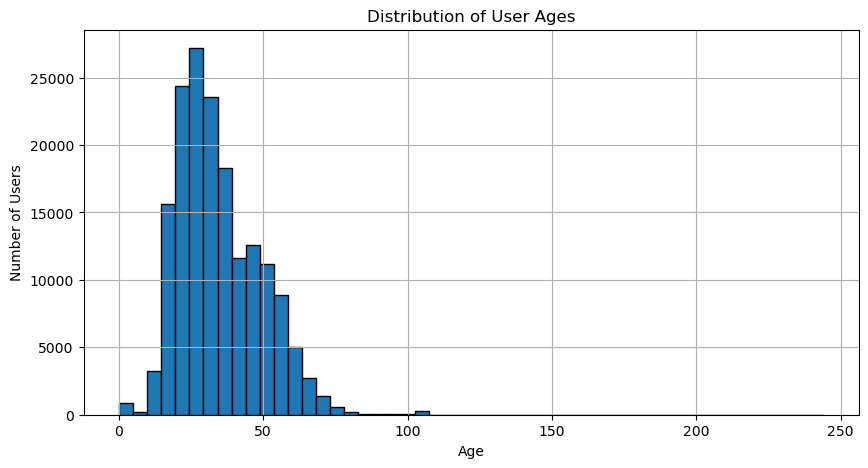

In [5]:
import matplotlib.pyplot as plt

# Plot age distribution (excluding NaNs)
plt.figure(figsize=(10, 5))
users['Age'].dropna().plot(kind='hist', bins=50, edgecolor='black')
plt.title("Distribution of User Ages")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.grid(True)
plt.show()

In [6]:
# Fill missing Age with -1
users.fillna({'Age': -1}, inplace=True)

# Drop rows in books with any missing values
books.dropna(subset=['Book-Author', 'Publisher', 'Image-URL-L'], inplace=True)

# Confirm changes
print("Remaining missing values:")
print("Users:", users.isnull().sum().sum())
print("Books:", books.isnull().sum().sum())

Remaining missing values:
Users: 0
Books: 0


Number of unique users: 105283
Number of unique books: 340556
Total ratings: 1149780



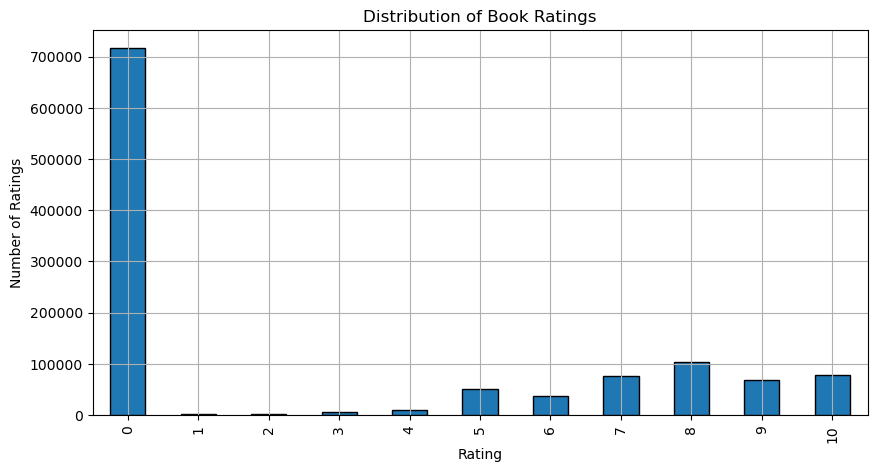

In [7]:
# Number of unique users and books
print(f"Number of unique users: {ratings['User-ID'].nunique()}")
print(f"Number of unique books: {ratings['ISBN'].nunique()}")
print(f"Total ratings: {len(ratings)}\n")

# Distribution of ratings
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ratings['Book-Rating'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.grid(True)
plt.show()

In the above we can see that there are lot of 0 ratings which technically means that they are not rated. For collaborative filter we need to remove all such values 0

Using 0s would:
	•	Drag down similarity values.
	•	Distort averages.
	•	Add false signals during predictions.

In [8]:
# Keep only real ratings (1 to 10)
ratings = ratings[ratings['Book-Rating'] != 0].copy()

# shape
print(f"Filtered ratings shape: {ratings.shape}")

Filtered ratings shape: (433671, 3)


In [9]:
# Count number of ratings per book
book_rating_counts = ratings.groupby('ISBN')['Book-Rating'].count().sort_values(ascending=False)

print("Top 10 most rated books:")
print(book_rating_counts.head(10), "\n")

print("Books with only one rating:", (book_rating_counts == 1).sum())
print("Books with fewer than 5 ratings:", (book_rating_counts < 5).sum())

Top 10 most rated books:
ISBN
0316666343    707
0971880107    581
0385504209    487
0312195516    383
0679781587    333
0060928336    320
059035342X    313
0142001740    307
0446672211    295
044023722X    281
Name: Book-Rating, dtype: int64 

Books with only one rating: 129621
Books with fewer than 5 ratings: 171438


In [10]:
# Count number of ratings per user
user_rating_counts = ratings.groupby('User-ID')['Book-Rating'].count().sort_values(ascending=False)

print("Top 10 most active users:")
print(user_rating_counts.head(10), "\n")

print("Users with only one rating:", (user_rating_counts == 1).sum())
print("Users with fewer than 5 ratings:", (user_rating_counts < 5).sum())

Top 10 most active users:
User-ID
11676     8524
98391     5802
153662    1969
189835    1906
23902     1395
76499     1036
171118    1035
235105    1023
16795      968
248718     948
Name: Book-Rating, dtype: int64 

Users with only one rating: 45382
Users with fewer than 5 ratings: 63585


In [11]:
# Step 1: Filter dataset to avoid pivot crash
book_counts = ratings['ISBN'].value_counts()
user_counts = ratings['User-ID'].value_counts()

filtered_ratings = ratings[
    ratings['ISBN'].isin(book_counts[book_counts >= 3].index) &
    ratings['User-ID'].isin(user_counts[user_counts >= 3].index)
].copy()

# Step 2: Build the user-item matrix safely
user_item_matrix = filtered_ratings.pivot(index='User-ID', columns='ISBN', values='Book-Rating')

print(f"Matrix shape: {user_item_matrix.shape}")

Matrix shape: (21181, 29967)


In [12]:
# Compute user mean ratings
user_means = user_item_matrix.mean(axis=1)

# Subtract user mean from each rating (mean normalization)
user_item_centered = user_item_matrix.sub(user_means, axis=0)

# Preview a few rows
user_item_centered.head()

ISBN,0 907 062 008,0/330/25864/8,0000000000,0000000000000,0001055666,0002005018,0002005115,0002116286,0002239183,0002240114,...,9871138148,987932504,9895550138,9994770934,B.1086903,B00005WN5U,B00009EF82,B0000AA9IZ,O67174142X,"\0432534220\"""""
User-ID,,,,,,,,,,,,,,,,,,,,,
8,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Transpose to get books as rows (each row = book vector)
item_vectors = user_item_centered.T

# Fill NaNs with 0 for similarity computation
item_vectors_filled = item_vectors.fillna(0)

# Compute cosine similarity between books
item_similarity_matrix = pd.DataFrame(
    cosine_similarity(item_vectors_filled),
    index=item_vectors_filled.index,
    columns=item_vectors_filled.index
)

# Preview a slice of the similarity matrix
item_similarity_matrix.iloc[:5, :5]

ISBN,0 907 062 008,0/330/25864/8,0000000000,0000000000000,0001055666
ISBN,,,,,
0 907 062 008,1.0,0.0,0.00000,0.0,0.00000
0/330/25864/8,0.0,0.0,0.00000,0.0,0.00000
0000000000,0.0,0.0,1.00000,0.0,0.44529
0000000000000,0.0,0.0,0.00000,0.0,0.00000
0001055666,0.0,0.0,0.44529,0.0,1.00000


In [14]:
from sklearn.model_selection import train_test_split

# Step 1: Shuffle and split on (user, book) pairs
train_df, test_df = train_test_split(
    filtered_ratings,  # use your filtered dataset here
    test_size=0.25,
    random_state=42
)

# Step 2: Ensure all test users are in train
# If not, move their ratings to train
test_users = set(test_df['User-ID'])
train_users = set(train_df['User-ID'])

missing_users = test_users - train_users
if missing_users:
    print(f"Moving {len(missing_users)} user(s) from test back to train to satisfy overlap.")

    move_back = test_df[test_df['User-ID'].isin(missing_users)]
    train_df = pd.concat([train_df, move_back])
    test_df = test_df[~test_df['User-ID'].isin(missing_users)]

# Final shapes
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Moving 855 user(s) from test back to train to satisfy overlap.
Training set size: 159745
Test set size: 51611


In [15]:
def predict_rating(user_id, isbn, user_item_train, similarity_matrix, k=5, user_means=None, global_mean=None):
    if isbn not in similarity_matrix.columns or user_id not in user_item_train.index:
        # Fallback: unknown book or user
        return user_means.get(user_id, global_mean)

    # Books the user has rated in training set
    user_rated_books = user_item_train.loc[user_id].dropna()
    
    if len(user_rated_books) == 0:
        return user_means.get(user_id, global_mean)

    # Get similarity scores of those books with the target book
    similarities = similarity_matrix[isbn].reindex(user_rated_books.index).dropna()
    
    # Get top-k similar books the user rated
    top_k = similarities.abs().sort_values(ascending=False).head(k)
    
    if top_k.empty:
        return user_means.get(user_id, global_mean)

    # Ratings for the top-k similar books
    ratings = user_rated_books[top_k.index]

    # Weighted sum of ratings
    numerator = (ratings * similarities[top_k.index]).sum()
    denominator = similarities[top_k.index].abs().sum()

    if denominator == 0:
        return user_means.get(user_id, global_mean)

    return numerator / denominator

In [16]:
# Recreate the user-item matrix from train data
train_matrix = train_df.pivot(index='User-ID', columns='ISBN', values='Book-Rating')

# Mean ratings per user in training set
user_means = train_matrix.mean(axis=1)

# Global mean rating across all users
global_mean = train_df['Book-Rating'].mean()

In [17]:
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error

def evaluate_cf(test_df, user_item_train, similarity_matrix, user_means, global_mean, k):
    predictions = []
    truths = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Evaluating k={k}"):
        user_id = row['User-ID']
        isbn = row['ISBN']
        true_rating = row['Book-Rating']

        pred_rating = predict_rating(
            user_id=user_id,
            isbn=isbn,
            user_item_train=user_item_train,
            similarity_matrix=similarity_matrix,
            k=k,
            user_means=user_means,
            global_mean=global_mean
        )

        predictions.append(pred_rating)
        truths.append(true_rating)

    mad = mean_absolute_error(truths, predictions)
    return mad

In [18]:
# Example: k = 10
mad_k10 = evaluate_cf(
    test_df=test_df,
    user_item_train=train_matrix,
    similarity_matrix=item_similarity_matrix,
    user_means=user_means,
    global_mean=global_mean,
    k=10
)

print(f"MAD for k=10: {mad_k10:.4f}")

Evaluating k=10: 100%|██████████| 51611/51611 [00:19<00:00, 2638.18it/s]

MAD for k=10: 7.7092


In [19]:
k_values = [5, 10, 15, 20, 50, 100]
mad_scores = {}

for k in k_values:
    mad = evaluate_cf(
        test_df=test_df,
        user_item_train=train_matrix,
        similarity_matrix=item_similarity_matrix,
        user_means=user_means,
        global_mean=global_mean,
        k=k
    )
    mad_scores[k] = mad
    print(f"MAD for k={k}: {mad:.4f}")

Evaluating k=5: 100%|██████████| 51611/51611 [00:19<00:00, 2689.90it/s]


MAD for k=5: 7.6772


Evaluating k=10: 100%|██████████| 51611/51611 [00:20<00:00, 2575.18it/s]


MAD for k=10: 7.7092


Evaluating k=15: 100%|██████████| 51611/51611 [00:18<00:00, 2737.65it/s]


...

MAD for k=20: 7.7173


Evaluating k=50: 100%|██████████| 51611/51611 [00:20<00:00, 2541.30it/s]


MAD for k=50: 7.7077


Evaluating k=100: 100%|██████████| 51611/51611 [00:20<00:00, 2547.63it/s]

MAD for k=100: 7.6981


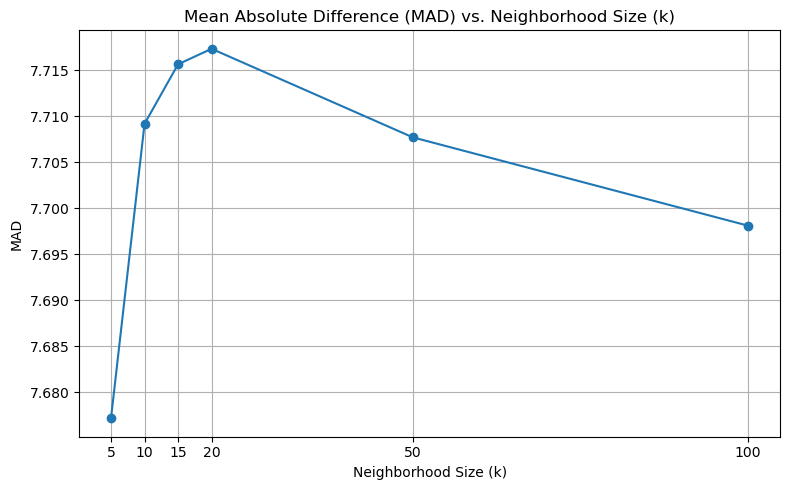

In [20]:
import matplotlib.pyplot as plt

# Plot MAD scores
plt.figure(figsize=(8, 5))
plt.plot(mad_scores.keys(), mad_scores.values(), marker='o', linestyle='-')
plt.title("Mean Absolute Difference (MAD) vs. Neighborhood Size (k)")
plt.xlabel("Neighborhood Size (k)")
plt.ylabel("MAD")
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [21]:
train_ratios = list(range(60, 95, 5))  # 60 to 90 in steps of 5
mad_by_ratio = {}

for ratio in train_ratios:
    print(f"\n🔁 Evaluating for Train Ratio = {ratio}%")

    train_df_r, test_df_r = train_test_split(
        filtered_ratings, 
        test_size=(1 - ratio / 100),
        random_state=42
    )

    # Ensure test users exist in train
    test_users = set(test_df_r['User-ID'])
    train_users = set(train_df_r['User-ID'])
    missing_users = test_users - train_users
    if missing_users:
        move_back = test_df_r[test_df_r['User-ID'].isin(missing_users)]
        train_df_r = pd.concat([train_df_r, move_back])
        test_df_r = test_df_r[~test_df_r['User-ID'].isin(missing_users)]

    # Recreate train matrix and means
    train_matrix_r = train_df_r.pivot(index='User-ID', columns='ISBN', values='Book-Rating')
    user_means_r = train_matrix_r.mean(axis=1)
    global_mean_r = train_df_r['Book-Rating'].mean()

    # Predict with fixed k=5
    mad = evaluate_cf(
        test_df=test_df_r,
        user_item_train=train_matrix_r,
        similarity_matrix=item_similarity_matrix,
        user_means=user_means_r,
        global_mean=global_mean_r,
        k=5
    )

    mad_by_ratio[ratio] = mad
    print(f"MAD at {ratio}% training: {mad:.4f}")


🔁 Evaluating for Train Ratio = 60%


Evaluating k=5: 100%|██████████| 81440/81440 [00:29<00:00, 2751.50it/s]


MAD at 60% training: 7.6553

🔁 Evaluating for Train Ratio = 65%


Evaluating k=5: 100%|██████████| 71670/71670 [00:26<00:00, 2750.08it/s]


MAD at 65% training: 7.6600

🔁 Evaluating for Train Ratio = 70%


...

MAD at 80% training: 7.6809

🔁 Evaluating for Train Ratio = 85%


Evaluating k=5: 100%|██████████| 31122/31122 [00:11<00:00, 2661.88it/s]


MAD at 85% training: 7.6951

🔁 Evaluating for Train Ratio = 90%


Evaluating k=5: 100%|██████████| 20806/20806 [00:07<00:00, 2613.79it/s]

MAD at 90% training: 7.7418


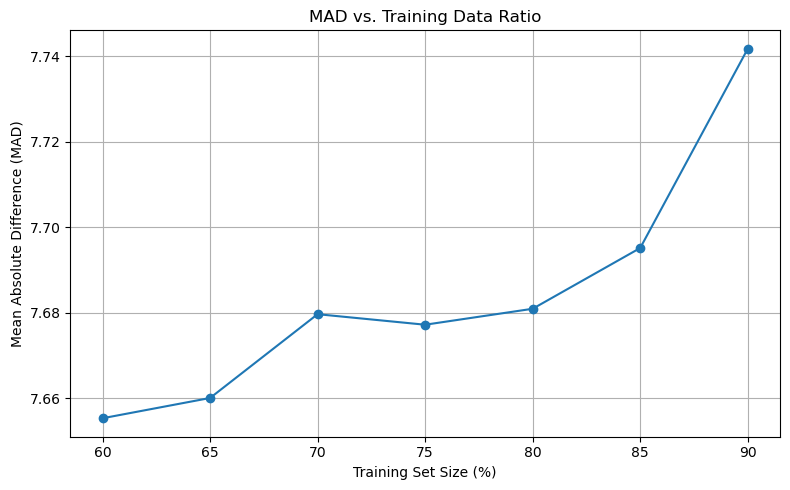

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(list(mad_by_ratio.keys()), list(mad_by_ratio.values()), marker='o')
plt.title("MAD vs. Training Data Ratio")
plt.xlabel("Training Set Size (%)")
plt.ylabel("Mean Absolute Difference (MAD)")
plt.grid(True)
plt.xticks(train_ratios)
plt.tight_layout()
plt.show()

In [23]:
def predict_rating_with_bias(user_id, isbn, user_item_train, similarity_matrix, k, user_means, global_mean):
    if isbn not in similarity_matrix.columns or user_id not in user_item_train.index:
        return user_means.get(user_id, global_mean)

    # Books the user has rated
    user_rated_books = user_item_train.loc[user_id].dropna()

    if user_rated_books.empty:
        return user_means.get(user_id, global_mean)

    # Similarities between target book and books the user rated
    similarities = similarity_matrix[isbn].reindex(user_rated_books.index).dropna()

    # Top-k similar books
    top_k = similarities.abs().sort_values(ascending=False).head(k)
    if top_k.empty:
        return user_means.get(user_id, global_mean)

    # Ratings and similarities of top-k books
    ratings = user_rated_books[top_k.index]
    sims = similarities[top_k.index]

    # User bias (b_u = user mean - global mean)
    b_u = user_means.get(user_id, global_mean) - global_mean

    # Baseline estimate
    baseline = global_mean + b_u

    # Weighted deviation from user's mean
    numerator = ((ratings - user_means.get(user_id, global_mean)) * sims).sum()
    denominator = sims.abs().sum()

    if denominator == 0:
        return baseline

    return baseline + (numerator / denominator)

In [24]:
# Re-run MAD evaluation with new prediction logic
def evaluate_cf_with_bias(test_df, user_item_train, similarity_matrix, user_means, global_mean, k):
    predictions = []
    truths = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Evaluating k={k} with bias"):
        user_id = row['User-ID']
        isbn = row['ISBN']
        true_rating = row['Book-Rating']

        pred_rating = predict_rating_with_bias(
            user_id=user_id,
            isbn=isbn,
            user_item_train=user_item_train,
            similarity_matrix=similarity_matrix,
            k=k,
            user_means=user_means,
            global_mean=global_mean
        )

        predictions.append(pred_rating)
        truths.append(true_rating)

    mad = mean_absolute_error(truths, predictions)
    return mad

In [25]:
mad_bias_k5 = evaluate_cf_with_bias(
    test_df=test_df,
    user_item_train=train_matrix,
    similarity_matrix=item_similarity_matrix,  # cosine matrix
    user_means=user_means,
    global_mean=global_mean,
    k=5
)

print(f"MAD (bias-corrected, k=5): {mad_bias_k5:.4f}")

Evaluating k=5 with bias: 100%|██████████| 51611/51611 [00:19<00:00, 2686.10it/s]

MAD (bias-corrected, k=5): 0.9157


In [26]:
k_values = [5, 10, 15, 20, 50, 100]
mad_bias_scores = {}

for k in k_values:
    mad = evaluate_cf_with_bias(
        test_df=test_df,
        user_item_train=train_matrix,
        similarity_matrix=item_similarity_matrix,
        user_means=user_means,
        global_mean=global_mean,
        k=k
    )
    mad_bias_scores[k] = mad
    print(f"MAD (bias-corrected) for k={k}: {mad:.4f}")

Evaluating k=5 with bias: 100%|██████████| 51611/51611 [00:18<00:00, 2759.35it/s]


MAD (bias-corrected) for k=5: 0.9157


Evaluating k=10 with bias: 100%|██████████| 51611/51611 [00:18<00:00, 2777.41it/s]


MAD (bias-corrected) for k=10: 0.8792


Evaluating k=15 with bias: 100%|██████████| 51611/51611 [00:18<00:00, 2768.71it/s]


...

MAD (bias-corrected) for k=20: 0.8502


Evaluating k=50 with bias: 100%|██████████| 51611/51611 [00:20<00:00, 2568.96it/s]


MAD (bias-corrected) for k=50: 0.8283


Evaluating k=100 with bias: 100%|██████████| 51611/51611 [00:19<00:00, 2651.22it/s]

MAD (bias-corrected) for k=100: 0.8207


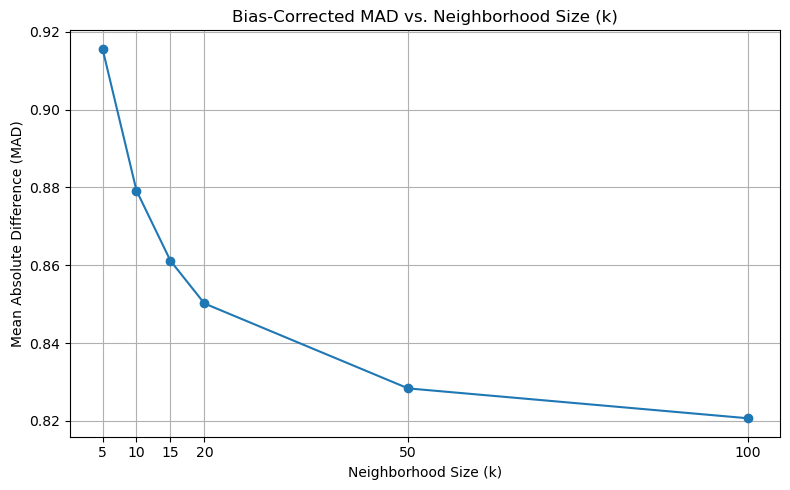

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(list(mad_bias_scores.keys()), list(mad_bias_scores.values()), marker='o', linestyle='-')
plt.title("Bias-Corrected MAD vs. Neighborhood Size (k)")
plt.xlabel("Neighborhood Size (k)")
plt.ylabel("Mean Absolute Difference (MAD)")
plt.grid(True)
plt.xticks(list(mad_bias_scores.keys()))
plt.tight_layout()
plt.show()

In [28]:
train_ratios = list(range(60, 95, 5))  # 60% to 90%
mad_by_ratio_bias = {}

for ratio in train_ratios:
    print(f"\n🔁 Evaluating for Train Ratio = {ratio}%")

    # Step 1: Split ratings
    train_df_r, test_df_r = train_test_split(
        filtered_ratings, 
        test_size=(1 - ratio / 100), 
        random_state=42
    )

    # Step 2: Ensure all test users exist in train
    test_users = set(test_df_r['User-ID'])
    train_users = set(train_df_r['User-ID'])
    missing_users = test_users - train_users
    if missing_users:
        move_back = test_df_r[test_df_r['User-ID'].isin(missing_users)]
        train_df_r = pd.concat([train_df_r, move_back])
        test_df_r = test_df_r[~test_df_r['User-ID'].isin(missing_users)]

    # Step 3: Build train matrix and means
    train_matrix_r = train_df_r.pivot(index='User-ID', columns='ISBN', values='Book-Rating')
    user_means_r = train_matrix_r.mean(axis=1)
    global_mean_r = train_df_r['Book-Rating'].mean()

    # Step 4: Evaluate
    mad = evaluate_cf_with_bias(
        test_df=test_df_r,
        user_item_train=train_matrix_r,
        similarity_matrix=item_similarity_matrix,
        user_means=user_means_r,
        global_mean=global_mean_r,
        k=50
    )

    mad_by_ratio_bias[ratio] = mad
    print(f"MAD (bias-corrected, {ratio}% train): {mad:.4f}")


🔁 Evaluating for Train Ratio = 60%


Evaluating k=50 with bias: 100%|██████████| 81440/81440 [00:28<00:00, 2813.78it/s]


MAD (bias-corrected, 60% train): 0.8566

🔁 Evaluating for Train Ratio = 65%


Evaluating k=50 with bias: 100%|██████████| 71670/71670 [00:27<00:00, 2596.27it/s]


MAD (bias-corrected, 65% train): 0.8481

🔁 Evaluating for Train Ratio = 70%


...

MAD (bias-corrected, 80% train): 0.8206

🔁 Evaluating for Train Ratio = 85%


Evaluating k=50 with bias: 100%|██████████| 31122/31122 [00:11<00:00, 2715.47it/s]


MAD (bias-corrected, 85% train): 0.8104

🔁 Evaluating for Train Ratio = 90%


Evaluating k=50 with bias: 100%|██████████| 20806/20806 [00:07<00:00, 2604.95it/s]

MAD (bias-corrected, 90% train): 0.8027


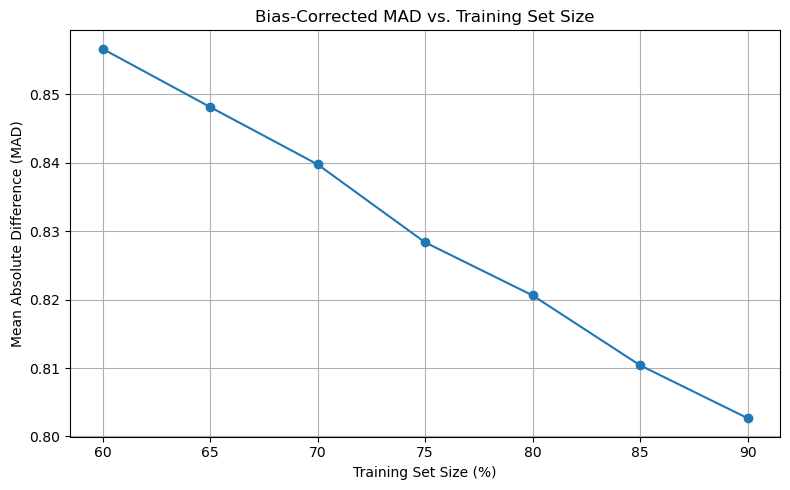

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(list(mad_by_ratio_bias.keys()), list(mad_by_ratio_bias.values()), marker='o', linestyle='-')
plt.title("Bias-Corrected MAD vs. Training Set Size")
plt.xlabel("Training Set Size (%)")
plt.ylabel("Mean Absolute Difference (MAD)")
plt.grid(True)
plt.xticks(train_ratios)
plt.tight_layout()
plt.show()

In [30]:
# Merge training ratings with book metadata
ratings_with_authors = pd.merge(train_df, books[['ISBN', 'Book-Author']], on='ISBN', how='left')

# Compute average rating per author from training data
author_avg_ratings = ratings_with_authors.groupby('Book-Author')['Book-Rating'].mean().to_dict()

# ISBN to Author map
isbn_to_author = books.set_index('ISBN')['Book-Author'].to_dict()

In [31]:
# Step 4: Define Hybrid Prediction Function (with author fallback)
def predict_rating_with_author_fallback(user_id, isbn, user_item_train, similarity_matrix, k, user_means, global_mean, author_avg_ratings, isbn_to_author):
    if isbn in similarity_matrix.columns and user_id in user_item_train.index:
        user_rated_books = user_item_train.loc[user_id].dropna()
        if not user_rated_books.empty:
            similarities = similarity_matrix[isbn].reindex(user_rated_books.index).dropna()
            top_k = similarities.abs().sort_values(ascending=False).head(k)
            if not top_k.empty:
                ratings = user_rated_books[top_k.index]
                sims = similarities[top_k.index]
                b_u = user_means.get(user_id, global_mean) - global_mean
                baseline = global_mean + b_u
                numerator = ((ratings - user_means.get(user_id, global_mean)) * sims).sum()
                denominator = sims.abs().sum()
                if denominator != 0:
                    return baseline + (numerator / denominator)

    # Fallback to author average
    author = isbn_to_author.get(isbn)
    if author and author in author_avg_ratings:
        return author_avg_ratings[author]

    # Final fallback
    return user_means.get(user_id, global_mean)

In [32]:
# Step 5: Evaluation function for hybrid model
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error

def evaluate_cf_hybrid(test_df, user_item_train, similarity_matrix, user_means, global_mean, k, author_avg_ratings, isbn_to_author):
    predictions = []
    truths = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Hybrid CF Evaluation (k={k})"):
        user_id = row['User-ID']
        isbn = row['ISBN']
        true_rating = row['Book-Rating']

        pred_rating = predict_rating_with_author_fallback(
            user_id=user_id,
            isbn=isbn,
            user_item_train=user_item_train,
            similarity_matrix=similarity_matrix,
            k=k,
            user_means=user_means,
            global_mean=global_mean,
            author_avg_ratings=author_avg_ratings,
            isbn_to_author=isbn_to_author
        )

        predictions.append(pred_rating)
        truths.append(true_rating)

    return mean_absolute_error(truths, predictions)

In [33]:
# Step 6: Also keep your original function (no author fallback) if not already defined
def evaluate_cf_with_bias(test_df, user_item_train, similarity_matrix, user_means, global_mean, k):
    predictions = []
    truths = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Bias-Corrected CF Evaluation (k={k})"):
        user_id = row['User-ID']
        isbn = row['ISBN']
        true_rating = row['Book-Rating']

        # Bias-corrected prediction (no author fallback)
        if isbn in similarity_matrix.columns and user_id in user_item_train.index:
            user_rated_books = user_item_train.loc[user_id].dropna()
            if not user_rated_books.empty:
                similarities = similarity_matrix[isbn].reindex(user_rated_books.index).dropna()
                top_k = similarities.abs().sort_values(ascending=False).head(k)
                if not top_k.empty:
                    ratings = user_rated_books[top_k.index]
                    sims = similarities[top_k.index]
                    b_u = user_means.get(user_id, global_mean) - global_mean
                    baseline = global_mean + b_u
                    numerator = ((ratings - user_means.get(user_id, global_mean)) * sims).sum()
                    denominator = sims.abs().sum()
                    if denominator != 0:
                        pred_rating = baseline + (numerator / denominator)
                        predictions.append(pred_rating)
                        truths.append(true_rating)
                        continue

        # fallback: user mean or global mean
        predictions.append(user_means.get(user_id, global_mean))
        truths.append(true_rating)

    return mean_absolute_error(truths, predictions)

In [34]:
# Step 7: Run and compare both models
mad_bias_k50 = evaluate_cf_with_bias(
    test_df=test_df,
    user_item_train=train_matrix,
    similarity_matrix=item_similarity_matrix,
    user_means=user_means,
    global_mean=global_mean,
    k=50
)

mad_hybrid_k50 = evaluate_cf_hybrid(
    test_df=test_df,
    user_item_train=train_matrix,
    similarity_matrix=item_similarity_matrix,
    user_means=user_means,
    global_mean=global_mean,
    k=50,
    author_avg_ratings=author_avg_ratings,
    isbn_to_author=isbn_to_author
)

# Step 8: Print both MAD scores side-by-side
print("🔍 MAD Score Comparison (k=50)")
print(f"Bias-Corrected CF Only        : {mad_bias_k50:.4f}")
print(f"Hybrid (CF + Author Fallback) : {mad_hybrid_k50:.4f}")

Hybrid CF Evaluation (k=50): 100%|██████████| 51611/51611 [00:19<00:00, 2601.79it/s]

🔍 MAD Score Comparison (k=50)
Bias-Corrected CF Only        : 0.8283
Hybrid (CF + Author Fallback) : 0.8460
